# Malli 1: Oma CNN

Tässä notebookissa rakennetaan ja koulutetaan oma konvoluutioverkko alusta alkaen.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path('..').resolve()))
sys.path.append(str(Path('..', 'src').resolve()))

from data_pipeline import create_generators
from models import build_simple_cnn
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = '../dataset/structured'
BATCH_SIZE = 16
IMAGE_SIZE = (224, 224)
EPOCHS = 10

train_gen, val_gen, test_gen = create_generators(DATA_DIR, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE)
NUM_CLASSES = len(train_gen.class_indices)
INPUT_SHAPE = (*IMAGE_SIZE, 3)

Found 149 images belonging to 2 classes.


Found 31 images belonging to 2 classes.


Found 34 images belonging to 2 classes.


In [3]:
model = build_simple_cnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\teemu\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,186 (84.86 MB)

 Trainable params: 22,245,186 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    verbose=1,
)

Epoch 1/10


 1/10 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.8000 - loss: 0.6384

 2/10 ━━━━━━━━━━━━━━━━━━━━ 5s 626ms/step - accuracy: 0.7810 - loss: 4.9680

 3/10 ━━━━━━━━━━━━━━━━━━━━ 4s 594ms/step - accuracy: 0.7819 - loss: 5.5951

 4/10 ━━━━━━━━━━━━━━━━━━━━ 3s 552ms/step - accuracy: 0.7704 - loss: 5.5411

...

 7/10 ━━━━━━━━━━━━━━━━━━━━ 1s 485ms/step - accuracy: 0.7902 - loss: 0.5011

 8/10 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step - accuracy: 0.7862 - loss: 0.5012

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.7824 - loss: 0.5019

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.7800 - loss: 0.5023

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 522ms/step - accuracy: 0.7584 - loss: 0.5054 - val_accuracy: 0.7742 - val_loss: 0.4409


In [5]:
test_loss, test_acc = model.evaluate(test_gen)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.4375 - loss: 0.8840

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.5781 - loss: 0.7134

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.7353 - loss: 0.5222


Test loss: 0.5222
Test accuracy: 0.7353


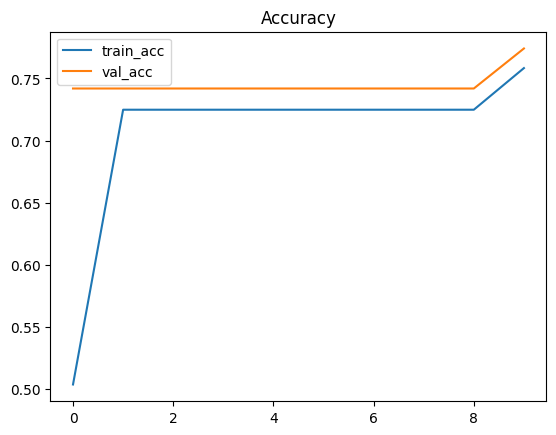

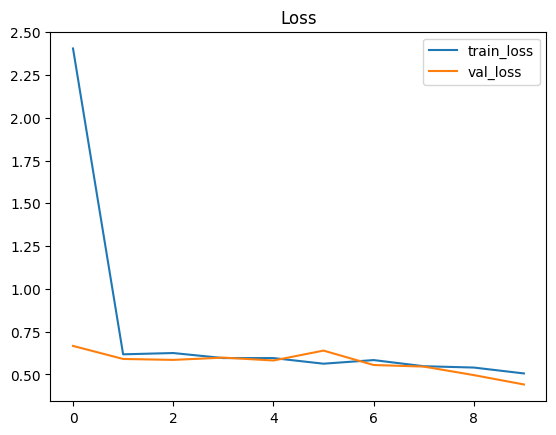

In [6]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()
plt.show()

## Tulokset
Tässä notebookissa näkyvät Malli 1:n tulokset suorituksen jälkeen:
- `test_loss` ja `test_accuracy`
- harjoitus- ja validointitarkkuuden sekä tappion käyrät

Jos haluat nähdä samat tulokset selaimessa, avaa `notebooks/02_own_cnn.html`.
Projektin yhteenveto ja vertailu löytyvät `report/report.md` -tiedostosta.